### Mini ML Model for Loan Default Risk Prediction

In [12]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

#### 1. Load the Dataset
First, let's load the `Loan_Default_Risk_Prediction_Dataset.csv` file into a pandas DataFrame and display its first few rows and information to understand its structure.

In [13]:
# Load the dataset
df = pd.read_csv('/content/Loan_Default_Risk_Prediction_Dataset.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Default
0,LP1000,Male,Yes,3,Graduate,Yes,16337,7673,303,120,0,Urban,0
1,LP1001,Female,No,3,Not Graduate,No,24986,6949,245,240,1,Semiurban,0
2,LP1002,Male,Yes,2,Not Graduate,Yes,8812,6882,647,300,1,Semiurban,0
3,LP1003,Male,Yes,0,Not Graduate,Yes,6820,1906,571,180,1,Urban,1
4,LP1004,Male,No,3,Graduate,No,14716,3086,566,180,1,Semiurban,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            200 non-null    object
 1   Gender             200 non-null    object
 2   Married            200 non-null    object
 3   Dependents         200 non-null    int64 
 4   Education          200 non-null    object
 5   Self_Employed      200 non-null    object
 6   ApplicantIncome    200 non-null    int64 
 7   CoapplicantIncome  200 non-null    int64 
 8   LoanAmount         200 non-null    int64 
 9   Loan_Amount_Term   200 non-null    int64 
 10  Credit_History     200 non-null    int64 
 11  Property_Area      200 non-null    object
 12  Loan_Default       200 non-null    int64 
dtypes: int64(7), object(6)
memory usage: 20.4+ KB


#### 2. Preprocessing
From the `df.info()` output, we can see that most columns are numerical. `Loan_Status` is likely our target variable. We need to handle categorical features and potentially missing values.

In [14]:
# Identify target variable and features
# Correcting the target variable name from 'Loan_Status' to 'Loan_Default'
target = 'Loan_Default'
features = df.drop(columns=[target]).columns

# Handle categorical features using Label Encoding for simplicity
# Identify categorical columns
categorical_cols = df[features].select_dtypes(include='object').columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Handle any potential missing values by filling with the mean for numerical columns
# (or mode/median, depending on distribution; for simplicity, using mean here)
for col in features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Convert target variable to numerical if it's not already (e.g., 'Y'/'N' to 1/0)
if df[target].dtype == 'object':
    df[target] = le.fit_transform(df[target])

print("\nDataFrame after preprocessing (first 5 rows):")
display(df.head())
print("\nDataFrame Info after preprocessing:")
df.info()


DataFrame after preprocessing (first 5 rows):


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Default
0,0,1,1,3,0,1,16337,7673,303,120,0,2,0
1,1,0,0,3,1,0,24986,6949,245,240,1,1,0
2,2,1,1,2,1,1,8812,6882,647,300,1,1,0
3,3,1,1,0,1,1,6820,1906,571,180,1,2,1
4,4,1,0,3,0,0,14716,3086,566,180,1,1,0



DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            200 non-null    int64
 1   Gender             200 non-null    int64
 2   Married            200 non-null    int64
 3   Dependents         200 non-null    int64
 4   Education          200 non-null    int64
 5   Self_Employed      200 non-null    int64
 6   ApplicantIncome    200 non-null    int64
 7   CoapplicantIncome  200 non-null    int64
 8   LoanAmount         200 non-null    int64
 9   Loan_Amount_Term   200 non-null    int64
 10  Credit_History     200 non-null    int64
 11  Property_Area      200 non-null    int64
 12  Loan_Default       200 non-null    int64
dtypes: int64(13)
memory usage: 20.4 KB


#### 3. Split Data
We'll split the data into training and testing sets to evaluate the model's performance on unseen data.

In [15]:
# Define X (features) and y (target)
target = 'Loan_Default' # Explicitly setting target to ensure correct column is used
X = df.drop(columns=[target])
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (160, 12)
Shape of X_test: (40, 12)
Shape of y_train: (160,)
Shape of y_test: (40,)


#### 4. Train a Simple Classification Model
For this mini ML model, we'll use Logistic Regression, a common and interpretable algorithm for binary classification.

In [17]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### 5. Evaluate the Model
Finally, let's evaluate the model's performance on the test set using common classification metrics like accuracy, a classification report, and a confusion matrix.

In [18]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)


Accuracy: 0.7750

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        31
           1       0.00      0.00      0.00         9

    accuracy                           0.78        40
   macro avg       0.39      0.50      0.44        40
weighted avg       0.60      0.78      0.68        40


Confusion Matrix:
[[31  0]
 [ 9  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 6. Train and Evaluate a Random Forest Classifier
Let's try a more powerful classification algorithm, the Random Forest, to see if it yields better results, especially given the `UndefinedMetricWarning` with Logistic Regression.

In [19]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


Now, let's evaluate the performance of the Random Forest model on the test set.

In [20]:
# Make predictions on the test set using Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(report_rf)
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)


Random Forest Accuracy: 0.7500

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86        31
           1       0.00      0.00      0.00         9

    accuracy                           0.75        40
   macro avg       0.38      0.48      0.43        40
weighted avg       0.60      0.75      0.66        40


Random Forest Confusion Matrix:
[[30  1]
 [ 9  0]]


#### 7. Visualize Feature Importances of Random Forest Model
Understanding feature importances helps in interpreting the model and potentially in feature selection for future iterations. Let's visualize the top features.

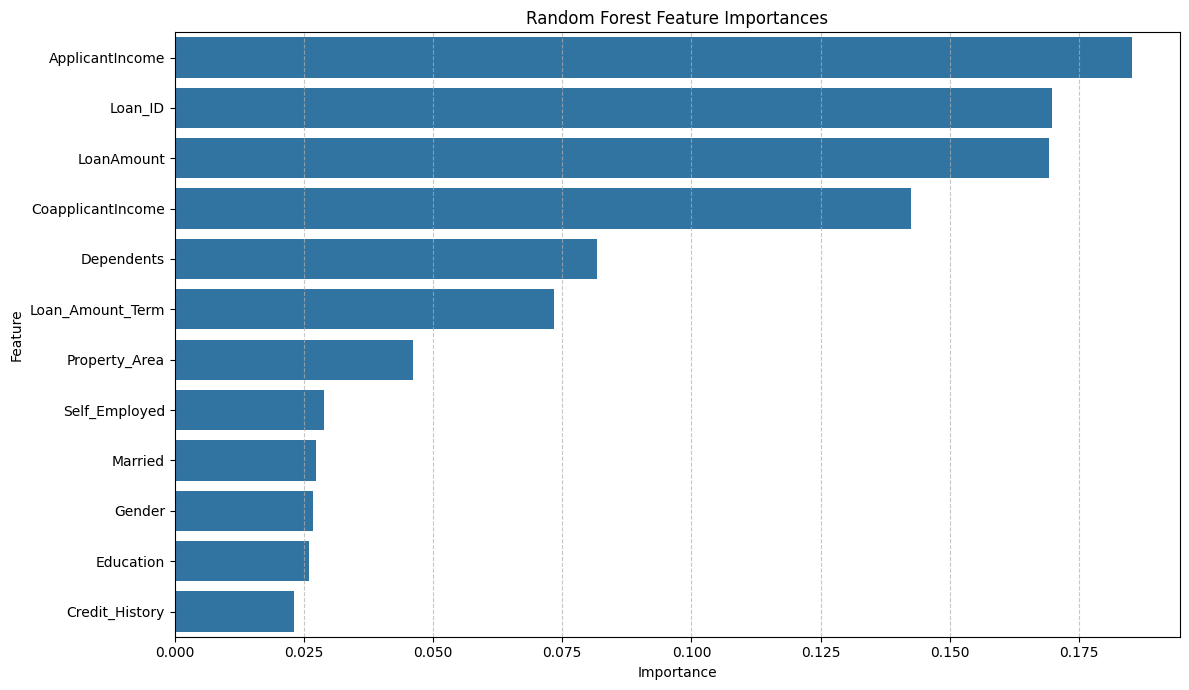

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 8. Compare Random Forest Accuracy with Logistic Regression
It's important to compare the performance of different models to determine which one is more suitable for the task. Let's compare the accuracy of the Random Forest model against the Logistic Regression model.

In [23]:
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

if accuracy_rf > accuracy:
    print("\nRandom Forest Classifier performed better than Logistic Regression.")
elif accuracy_rf < accuracy:
    print("\nLogistic Regression performed better than Random Forest Classifier.")
else:
    print("\nBoth models performed similarly.")

Logistic Regression Accuracy: 0.7750
Random Forest Classifier Accuracy: 0.7500

Logistic Regression performed better than Random Forest Classifier.


#### 9. Display Confusion Matrices for Both Models
A confusion matrix provides a more detailed breakdown of model performance, showing true positives, true negatives, false positives, and false negatives.


Logistic Regression Confusion Matrix:
[[31  0]
 [ 9  0]]

Random Forest Classifier Confusion Matrix:
[[30  1]
 [ 9  0]]


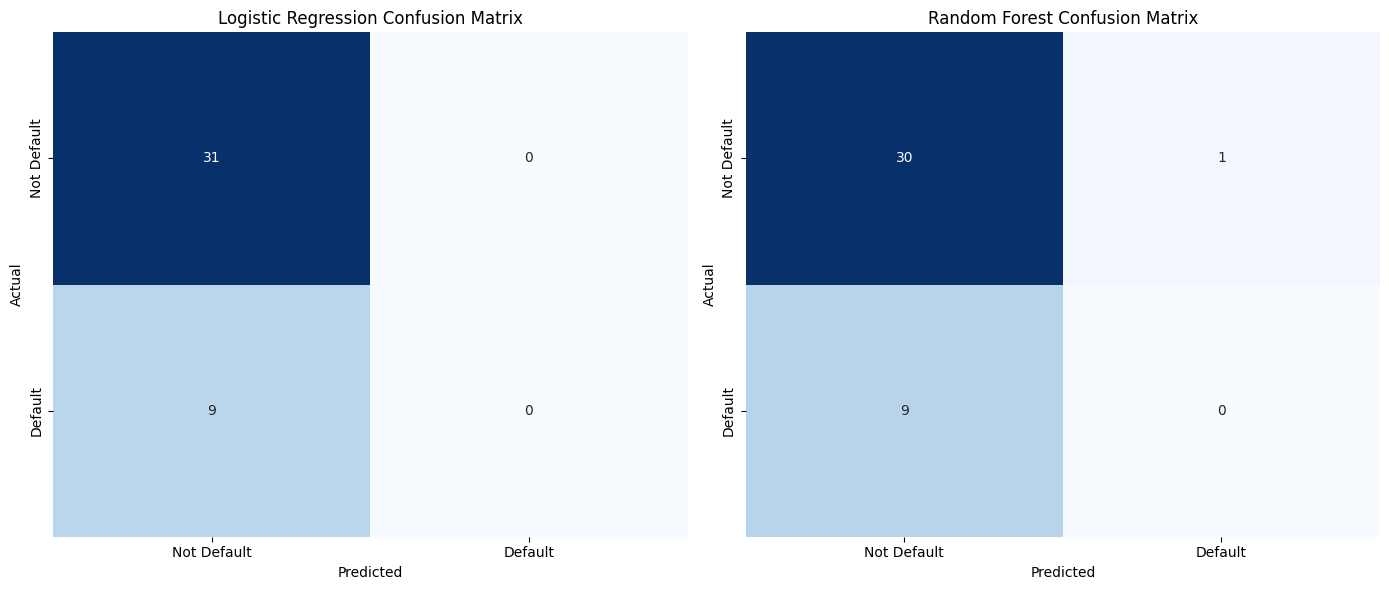

In [24]:
print("\nLogistic Regression Confusion Matrix:")
print(conf_matrix)

print("\nRandom Forest Classifier Confusion Matrix:")
print(conf_matrix_rf)

# Optionally, visualize the confusion matrices for better understanding
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].xaxis.set_ticklabels(['Not Default', 'Default'])
axes[0].yaxis.set_ticklabels(['Not Default', 'Default'])

sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].xaxis.set_ticklabels(['Not Default', 'Default'])
axes[1].yaxis.set_ticklabels(['Not Default', 'Default'])

plt.tight_layout()
plt.show()

#### 10. Calculate Precision and Recall for Both Models
Precision and recall are crucial metrics, especially in imbalanced datasets. Let's explicitly calculate and display them for both models.

In [25]:
from sklearn.metrics import precision_score, recall_score

# Logistic Regression Scores
precision_lr = precision_score(y_test, y_pred, zero_division=0)
recall_lr = recall_score(y_test, y_pred, zero_division=0)

print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")

# Random Forest Scores
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)

print(f"\nRandom Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")

Logistic Regression Precision: 0.0000
Logistic Regression Recall: 0.0000

Random Forest Precision: 0.0000
Random Forest Recall: 0.0000


#### 11. Retrain Models After Dropping 'Loan_ID'
As `Loan_ID` is an identifier and not a predictive feature, let's remove it from our feature set and re-evaluate both models.

In [26]:
# Redefine X (features) by dropping 'Loan_ID' as well
X_no_id = df.drop(columns=[target, 'Loan_ID'])
y_no_id = df[target]

# Split the data into training and testing sets with the updated X
X_train_no_id, X_test_no_id, y_train_no_id, y_test_no_id = train_test_split(X_no_id, y_no_id, test_size=0.2, random_state=42, stratify=y_no_id)

print(f"Shape of X_train (without Loan_ID): {X_train_no_id.shape}")
print(f"Shape of X_test (without Loan_ID): {X_test_no_id.shape}")

Shape of X_train (without Loan_ID): (160, 11)
Shape of X_test (without Loan_ID): (40, 11)


##### Retraining Logistic Regression (without Loan_ID)

In [27]:
# Initialize and train the Logistic Regression model with features excluding 'Loan_ID'
model_no_id_lr = LogisticRegression(random_state=42, solver='liblinear')
model_no_id_lr.fit(X_train_no_id, y_train_no_id)

# Make predictions and evaluate
y_pred_no_id_lr = model_no_id_lr.predict(X_test_no_id)
accuracy_no_id_lr = accuracy_score(y_test_no_id, y_pred_no_id_lr)
report_no_id_lr = classification_report(y_test_no_id, y_pred_no_id_lr, zero_division=0)
conf_matrix_no_id_lr = confusion_matrix(y_test_no_id, y_pred_no_id_lr)
precision_no_id_lr = precision_score(y_test_no_id, y_pred_no_id_lr, zero_division=0)
recall_no_id_lr = recall_score(y_test_no_id, y_pred_no_id_lr, zero_division=0)

print("Logistic Regression (without Loan_ID) trained and evaluated successfully.")

Logistic Regression (without Loan_ID) trained and evaluated successfully.


##### Retraining Random Forest Classifier (without Loan_ID)

In [29]:
# Initialize and train the Random Forest Classifier model with features excluding 'Loan_ID'
rf_model_no_id = RandomForestClassifier(random_state=42)
rf_model_no_id.fit(X_train_no_id, y_train_no_id)

# Make predictions and evaluate
y_pred_no_id_rf = rf_model_no_id.predict(X_test_no_id)
accuracy_no_id_rf = accuracy_score(y_test_no_id, y_pred_no_id_rf)
report_no_id_rf = classification_report(y_test_no_id, y_pred_no_id_rf, zero_division=0)
conf_matrix_no_id_rf = confusion_matrix(y_test_no_id, y_pred_no_id_rf)
precision_no_id_rf = precision_score(y_test_no_id, y_pred_no_id_rf, zero_division=0)
recall_no_id_rf = recall_score(y_test_no_id, y_pred_no_id_rf, zero_division=0)

print("Random Forest Classifier (without Loan_ID) trained and evaluated successfully.")

Random Forest Classifier (without Loan_ID) trained and evaluated successfully.


##### Comparison of Model Performances (without Loan_ID)


--- Logistic Regression (without Loan_ID) ---
Accuracy: 0.7750
Precision: 0.0000
Recall: 0.0000
Confusion Matrix:
[[31  0]
 [ 9  0]]

--- Random Forest Classifier (without Loan_ID) ---
Accuracy: 0.7250
Precision: 0.0000
Recall: 0.0000
Confusion Matrix:
[[29  2]
 [ 9  0]]


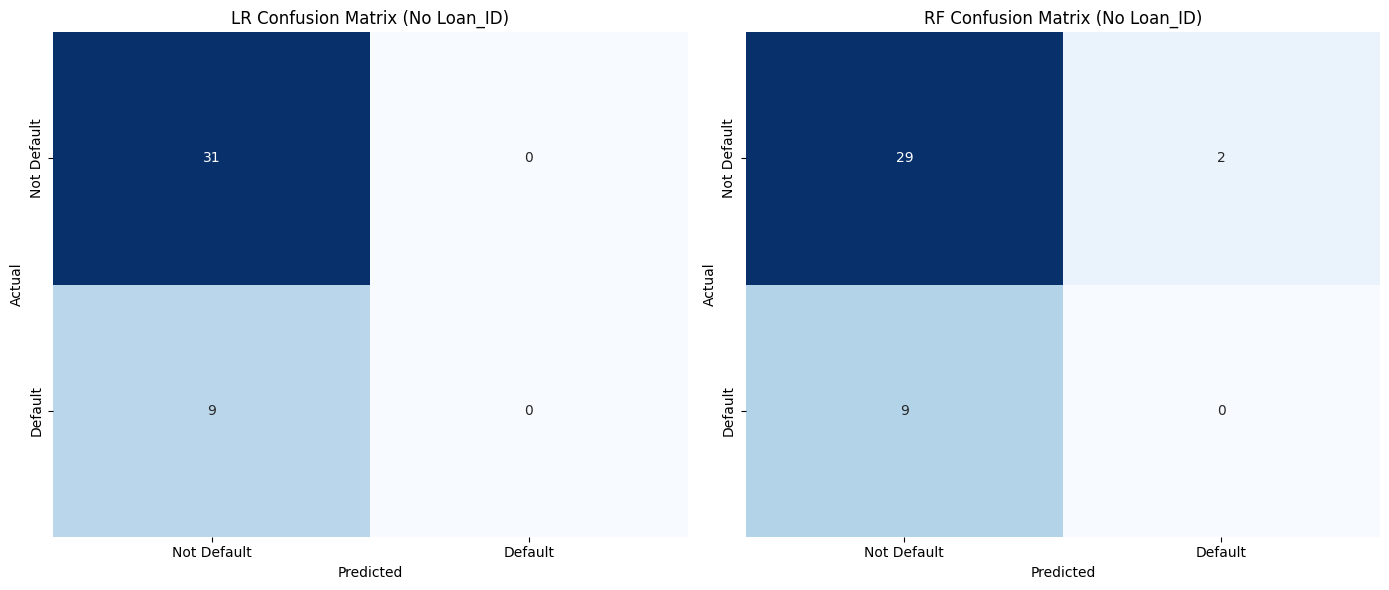

In [30]:
print("\n--- Logistic Regression (without Loan_ID) ---")
print(f"Accuracy: {accuracy_no_id_lr:.4f}")
print(f"Precision: {precision_no_id_lr:.4f}")
print(f"Recall: {recall_no_id_lr:.4f}")
print("Confusion Matrix:")
print(conf_matrix_no_id_lr)

print("\n--- Random Forest Classifier (without Loan_ID) ---")
print(f"Accuracy: {accuracy_no_id_rf:.4f}")
print(f"Precision: {precision_no_id_rf:.4f}")
print(f"Recall: {recall_no_id_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix_no_id_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_no_id_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('LR Confusion Matrix (No Loan_ID)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].xaxis.set_ticklabels(['Not Default', 'Default'])
axes[0].yaxis.set_ticklabels(['Not Default', 'Default'])

sns.heatmap(conf_matrix_no_id_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('RF Confusion Matrix (No Loan_ID)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].xaxis.set_ticklabels(['Not Default', 'Default'])
axes[1].yaxis.set_ticklabels(['Not Default', 'Default'])

plt.tight_layout()
plt.show()

#### 12. Push Work to GitHub Repository
To save this notebook to your GitHub repository, we'll use Git commands. You might need to set up Git credentials if you haven't already in this Colab session.

In [37]:
import os

# Define repository details
repo_url = 'https://github.com/koteswaraoposa-pixel/Innolift-intership.git'
repo_name = 'Innolift-intership'
repo_path = f'/content/{repo_name}' # Full path to the cloned repository

# Check if the repository already exists
if not os.path.exists(repo_path):
    # Clone the repository if it doesn't exist
    !git clone {repo_url} {repo_path}
    print(f"Cloned {repo_url} into {repo_path}")
else:
    print(f"Repository '{repo_name}' already exists at {repo_path}. Pulling latest changes...")
    # Navigate into the repository directory to pull changes
    %cd {repo_path}
    !git pull

# Ensure we are in the cloned repository directory for subsequent operations
%cd {repo_path}
print(f"Current working directory: {os.getcwd()}")

Repository 'Innolift-intership' already exists at /content/Innolift-intership. Pulling latest changes...
/content/Innolift-intership
Already up to date.
/content/Innolift-intership
Current working directory: /content/Innolift-intership


In [ ]:
### 12.1 Save the Notebook to the Repository

Before committing and pushing, please **manually save this Colab notebook** (`File` > `Save a copy in Drive` then download the `.ipynb` file, and upload it to the `Innolift-intership` folder within your cloned repository) or (`File` > `Save a copy as a GitHub Gist` / `Save a copy to GitHub` and select the appropriate repository and path).

Once you have saved the notebook named `Loan_Default_Risk_Prediction.ipynb` inside the `Innolift-intership` directory, run the next cell to add and commit the changes.

Before pushing, ensure you have set up your GitHub credentials. If you are using SSH, ensure your SSH key is added to your GitHub account and your Colab environment. If using HTTPS, you might be prompted for your username and Personal Access Token (PAT).

In [34]:
import os

repo_name = 'Innolift-intership'
repo_path = f'/content/{repo_name}' # Full path to the cloned repository

# Ensure we are in the repository directory before pushing
%cd {repo_path}
print(f"Navigated to repository directory: {os.getcwd()}")

# Add the notebook (assuming it has been manually saved in the repo_path)
notebook_filename = 'Loan_Default_Risk_Prediction.ipynb'
!git add {notebook_filename}

# Configure user info for git commit
!git config user.email "your_email@example.com" # Replace with your GitHub email
!git config user.name "Your GitHub Username" # Replace with your GitHub username

# Commit changes
!git commit -m "Add Loan Default Risk Prediction Notebook" # You can customize the commit message

# Push changes to the remote repository
!git push origin main # Or 'master', depending on your branch name

# Navigate back to the root directory of Colab
%cd /content
print(f"Navigated back to {os.getcwd()}")

[Errno 2] No such file or directory: '/content/Innolift-intership'
/content
Navigated to repository directory: /content
fatal: not a git repository (or any of the parent directories): .git
fatal: not in a git directory
fatal: not in a git directory
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
/content
Navigated back to /content


In [36]:
import os

repo_name = 'Innolift-intership'
repo_path = f'/content/{repo_name}' # Full path to the cloned repository

# Ensure we are in the repository directory
%cd {repo_path}
print(f"Current working directory: {os.getcwd()}")

!git status

/content/Innolift-intership
Current working directory: /content/Innolift-intership
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
